In [1]:
"""
How Learning to Control One Neuron Rewires a Neural Network
===========================================================
Allen Institute for Neural Dynamics — BCI Hackathon 2025

Three analysis aims:
  Aim 1 — Correlation network rewiring (bci_demo.ipynb data)
  Aim 2 — Photostimulation validation of rewired edges (photostim_demo.ipynb data)
  Aim 3 — Graph theory metrics + learning rule discrimination

Dependencies: numpy, pandas, scipy, matplotlib, networkx, hdmf_zarr, pynwb
"""

import os
import pickle
import hashlib
import warnings
from collections import defaultdict
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from pathlib import Path
from hdmf_zarr import NWBZarrIO

# ─── utility from the demo notebooks ────────────────────────────────────────
from utils.filter_roi_table import filter_roi_table, filter_dff


# ════════════════════════════════════════════════════════════════════════════
# 0.  DATA LOADING HELPERS
# ════════════════════════════════════════════════════════════════════════════

def load_session(session_name: str, data_root: str = "/data/brain-computer-interface-v2"):
    """Return an open NWBFile handle for one session."""
    session_dir = os.path.join(data_root, session_name)

    if not os.path.exists(session_dir):
        raise FileNotFoundError(f"Session directory not found: {session_dir}")

    nwb_files = [f for f in os.listdir(session_dir) if "nwb" in f]
    if not nwb_files:
        raise FileNotFoundError(f"No NWB file found in: {session_dir}")

    nwb_path = os.path.join(session_dir, nwb_files[0])
    with NWBZarrIO(str(nwb_path), "r") as io:
        nwbfile = io.read()
    return nwbfile


def extract_session_data(nwbfile):
    """
    Pull every array we need from one NWB file.

    Returns
    -------
    dict with keys:
        dff, frame_rate, epoch_table, trials, photostim,
        image_seg, cn_index, cleaned_dff, cleaned_roi_table
    """
    # Raw ΔF/F  (frames × neurons)
    dff = nwbfile.processing["processed"] \
                 .data_interfaces["dff"] \
                 .roi_response_series["dff"].data[:]

    frame_rate = nwbfile.imaging_planes["processed"].imaging_rate

    epoch_table = nwbfile.intervals["epochs"].to_dataframe()
    trials      = nwbfile.stimulus["Trials"].to_dataframe()
    photostim   = nwbfile.stimulus["PhotostimTrials"].to_dataframe()
    image_seg   = (nwbfile.processing["processed"]
                          .data_interfaces["image_segmentation"]
                          .plane_segmentations["roi_table"]
                          .to_dataframe())

    cn_index = trials.closest_roi.unique()[0]   # raw dff column index

    # Filtered dff (soma-only, cleaned)
    filtered_roi_table          = filter_roi_table(nwbfile)
    cleaned_dff, cleaned_roi_table = filter_dff(nwbfile, filtered_roi_table)

    # Map cn_index into cleaned array
    if cn_index in cleaned_roi_table.index:
        cn_clean = cleaned_roi_table.index.get_loc(cn_index)
    else:
        # Fall back to nearest soma
        cn_clean = np.argmin(np.abs(cleaned_roi_table.index - cn_index))

    return dict(dff=dff, frame_rate=frame_rate, epoch_table=epoch_table,
                trials=trials, photostim=photostim, image_seg=image_seg,
                cn_index=cn_index, cn_clean=cn_clean,
                cleaned_dff=cleaned_dff, cleaned_roi_table=cleaned_roi_table)


# ════════════════════════════════════════════════════════════════════════════
# AIM 1 — CORRELATION NETWORK REWIRING
# ════════════════════════════════════════════════════════════════════════════

def compute_cn_correlations(dff_epoch: np.ndarray, cn_col: int) -> np.ndarray:
    """
    Pearson r between the CN and every other neuron in dff_epoch.
    Returns array of length n_neurons (self-correlation at cn_col = 1.0).
    """
    cn_trace = dff_epoch[:, cn_col]
    n_neurons = dff_epoch.shape[1]
    correlations = np.array([
        pearsonr(cn_trace, dff_epoch[:, i])[0]
        for i in range(n_neurons)
    ])
    return correlations


def aim1_correlation_rewiring(data: dict, session_name: str, save_dir: str = "./results"):
    """
    Aim 1: Compare CN↔network correlations in spont_pre vs spont_post.

    Tests
    -----
    - Two-sample t-test on distribution shift
    - Cohen's d effect size
    - Per-neuron Δr = r_post − r_pre (the 'rewiring signature')
    """
    epoch_table  = data["epoch_table"]
    cleaned_dff  = data["cleaned_dff"]
    cn_col       = data["cn_clean"]

    # ── Epoch frame windows ──────────────────────────────────────────────────
    pre_row  = epoch_table[epoch_table.stimulus_name == "spont"]
    

    dff_pre  = cleaned_dff[pre_row.start_frame.item() : pre_row.stop_frame.item(),  :]
    # try:
    #     post_row = epoch_table[epoch_table.stimulus_name == "spont_post"]
    #     dff_post = cleaned_dff[post_row.start_frame.item(): post_row.stop_frame.item(), :]
    # except:
    #     post_row = epoch_table[epoch_table.stimulus_name == "spont_01"]
    #     # try:
    #     dff_post = cleaned_dff[post_row.start_frame.item(): post_row.stop_frame.item(), :]
    #     # except:
    #         # post_row = epoch_table[epoch_table.stimulus_name == "spont_01"]
    #         # import pdb; pdb.set_trace()

     # Try each known post-spontaneous epoch name in order of preference
    _post_candidates = ["spont_post", "spont_01", "spont_1"]
    post_row = None
    for _name in _post_candidates:
        _rows = epoch_table[epoch_table.stimulus_name == _name]
        if not _rows.empty:
            post_row = _rows.iloc[0]
            break

    if post_row is None:
        print(f"  ⚠  No post-BCI spontaneous epoch found (tried {_post_candidates}). "
              f"Available: {epoch_table.stimulus_name.tolist()}. Skipping session.")
        return None

    dff_post = cleaned_dff[int(post_row.start_frame) : int(post_row.stop_frame), :]

    # ── Correlations ─────────────────────────────────────────────────────────
    corr_pre  = compute_cn_correlations(dff_pre,  cn_col)
    corr_post = compute_cn_correlations(dff_post, cn_col)

    # Remove self-correlation
    mask = np.arange(len(corr_pre)) != cn_col
    corr_pre  = corr_pre[mask]
    corr_post = corr_post[mask]
    delta_r   = corr_post - corr_pre

    # ── Statistics ───────────────────────────────────────────────────────────
    t_stat, p_val = stats.ttest_ind(corr_pre, corr_post)
    pooled_std    = np.sqrt((corr_pre.std()**2 + corr_post.std()**2) / 2)
    cohens_d      = (corr_post.mean() - corr_pre.mean()) / pooled_std

    print("── Aim 1: Correlation rewiring ──────────────────────────────────")
    print(f"  mean r  pre : {corr_pre.mean():.4f}  ±{corr_pre.std():.4f}")
    print(f"  mean r  post: {corr_post.mean():.4f}  ±{corr_post.std():.4f}")
    print(f"  Δmean r     : {delta_r.mean():.4f}")
    print(f"  t={t_stat:.3f},  p={p_val:.4g},  Cohen's d={cohens_d:.3f}")
    print(f"  Neurons with Δr > 0.1 : {(delta_r > 0.1).sum()}")
    print(f"  Neurons with Δr < -0.1: {(delta_r < -0.1).sum()}")

    # ── Figure ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    subject_id = session_name[19:(19+6)]
    fig.suptitle(f"Aim 1 — CN Correlation Rewiring After BCI Learning ({subject_id})", fontsize=13, fontweight="bold")

    bins = np.linspace(-0.15, 0.35, 80)

    # Histogram comparison
    axes[0].hist(corr_pre,  bins=bins, histtype="step", color="#39b54a", lw=2, label="Pre-BCI")
    axes[0].hist(corr_post, bins=bins, histtype="step", color="#7B2D8B", lw=2, label="Post-BCI")
    axes[0].axvline(corr_pre.mean(),  ls="--", color="#39b54a", alpha=0.7)
    axes[0].axvline(corr_post.mean(), ls="--", color="#7B2D8B", alpha=0.7)
    axes[0].set_xlabel("Pearson r with CN")
    axes[0].set_ylabel("# Neuron Pairs")
    axes[0].set_title("Distribution Shift")
    axes[0].legend()
    axes[0].text(0.97, 0.95, f"p={p_val:.3g}\nd={cohens_d:.2f}",
                 ha="right", va="top", transform=axes[0].transAxes, fontsize=9)

    # Scatter: pre vs post
    axes[1].scatter(corr_pre, corr_post, alpha=0.5, s=20, c=delta_r, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    lim = max(abs(corr_pre).max(), abs(corr_post).max()) * 1.1
    axes[1].plot([-lim, lim], [-lim, lim], "k--", lw=1, alpha=0.4)
    axes[1].set_xlabel("r  (pre-BCI)")
    axes[1].set_ylabel("r  (post-BCI)")
    axes[1].set_title("Pre vs Post (colour = Δr)")

    # Δr distribution
    axes[2].hist(delta_r, bins=60, color="#e07b20", edgecolor="none")
    axes[2].axvline(0, color="black", lw=1)
    axes[2].axvline(delta_r.mean(), color="red", lw=2, ls="--", label=f"mean={delta_r.mean():.3f}")
    axes[2].set_xlabel("Δr  (post − pre)")
    axes[2].set_ylabel("# Neurons")
    axes[2].set_title("Per-Neuron Rewiring")
    axes[2].legend()

    plt.tight_layout()
    try:
        plt.savefig(os.path.join(save_dir, f"aim1_correlation_rewiring_{session_name}.png"), dpi=150)
    except:
        import pdb; pdb.set_trace()
    plt.show()

    return dict(corr_pre=corr_pre, corr_post=corr_post, delta_r=delta_r,
                t_stat=t_stat, p_val=p_val, cohens_d=cohens_d)


# ════════════════════════════════════════════════════════════════════════════
# AIM 2 — PHOTOSTIMULATION VALIDATION
# ════════════════════════════════════════════════════════════════════════════

def evoked_response(dff: np.ndarray,
                    photostim: pd.DataFrame,
                    stimulus_name: str,
                    post_stim_frames: int = 5) -> dict:
    """
    For each photostimulated neuron in a given epoch, measure the mean
    evoked ΔF/F in a post-stimulus window (artifact-excluded).

    Returns dict: { closest_roi → mean_evoked_dff_vector_over_all_neurons }
    """
    epoch_trials = photostim[photostim.stimulus_name == stimulus_name]
    evoked = {}

    for roi in epoch_trials.closest_roi.unique():
        trials_roi = epoch_trials[epoch_trials.closest_roi == roi]
        responses  = []
        for _, row in trials_roi.iterrows():
            sf = int(row.stop_frame)
            if sf + post_stim_frames >= dff.shape[0]:
                continue
            # Average ΔF/F across post-stim window for ALL neurons
            window = dff[sf : sf + post_stim_frames, :]  # (post_stim_frames × n_neurons)
            responses.append(window.mean(axis=0))
        if responses:
            evoked[roi] = np.mean(responses, axis=0)  # (n_neurons,)

    return evoked


def aim2_photostim_validation(data: dict, session_name: str, aim1_results: dict, save_dir: str = "./results"):
    """
    Aim 2: Do neurons with large Δr (Aim 1) also show larger evoked responses
    when THEY are photostimulated post- vs pre-BCI?

    Strategy
    --------
    For each photostimulated target T:
      - evoked_response_T_pre  = mean ΔF/F of T's neighbours after stim, pre-BCI epoch
      - evoked_response_T_post = same, post-BCI epoch
      - Δevoked_T              = post − pre  (scalar: mean over all neighbours)
    Then correlate Δevoked with the Δr of those same neurons (from Aim 1).
    """
    dff       = data["dff"]
    photostim = data["photostim"]
    delta_r   = aim1_results["delta_r"]

    epoch_names = photostim.stimulus_name.unique()
    pre_name    = [n for n in epoch_names if "photostim" in n and "post" not in n][0]
    post_names  = [n for n in epoch_names if "photostim" in n and "post" in n]
    post_name   = post_names[0] if post_names else None

    if post_name is None:
        print("  ⚠  No post-BCI photostim epoch found in this session — skipping Aim 2.")
        return None

    evoked_pre  = evoked_response(dff, photostim, pre_name)
    evoked_post = evoked_response(dff, photostim, post_name)

    # Neurons stimulated in both epochs
    shared_targets = sorted(set(evoked_pre.keys()) & set(evoked_post.keys()))

    delta_evoked_list = []  # Δevoked per target (mean over all recorded neighbours)
    delta_r_targets   = []  # Δr of the photostimulated target itself

    n_neurons = dff.shape[1]
    for target in shared_targets:
        if target >= n_neurons:
            continue
        delta_ev = evoked_post[target] - evoked_pre[target]  # (n_neurons,)
        delta_evoked_list.append(delta_ev.mean())

        # Map target index into cleaned delta_r
        # (delta_r has self-correlation removed; approximate with index)
        clean_idx = min(target, len(delta_r) - 1)
        delta_r_targets.append(delta_r[clean_idx])

    delta_evoked_arr = np.array(delta_evoked_list)
    delta_r_arr      = np.array(delta_r_targets)

    # ── Guard: drop any NaN / Inf entries from either array ──────────────────
    finite_mask      = np.isfinite(delta_r_arr) & np.isfinite(delta_evoked_arr)
    delta_r_arr      = delta_r_arr[finite_mask]
    delta_evoked_arr = delta_evoked_arr[finite_mask]

    print("\n── Aim 2: Photostimulation validation ───────────────────────────")
    print(f"  Shared photostim targets (after NaN drop): {len(delta_r_arr)}")

    # Need at least 3 pairs for a meaningful correlation
    if len(delta_r_arr) < 3:
        print("  ⚠  Too few valid pairs for correlation — skipping Aim 2 stats.")
        return None

    # Guard: if either array is constant, pearsonr returns NaN
    if delta_r_arr.std() == 0 or delta_evoked_arr.std() == 0:
        print("  ⚠  One array has zero variance — correlation undefined. Skipping.")
        return None

    r_val, p_val = pearsonr(delta_r_arr, delta_evoked_arr)
    print(f"  r(Δcorrelation, Δevoked) = {r_val:.3f},  p = {p_val:.4g}")

    # ── Permutation test (NaN-safe) ───────────────────────────────────────────
    rng_perm = np.random.default_rng(42)

    def _safe_pearsonr(a, b):
        """Return pearsonr r, or NaN if either input is constant."""
        if a.std() == 0 or b.std() == 0:
            return np.nan
        return pearsonr(a, b)[0]

    n_perm = 5000
    perm_r = np.array([
        _safe_pearsonr(rng_perm.permutation(delta_r_arr), delta_evoked_arr)
        for _ in range(n_perm)
    ])
    perm_r = perm_r[np.isfinite(perm_r)]   # drop any NaN permutations
    perm_p = (np.abs(perm_r) >= np.abs(r_val)).mean()
    print(f"  Permutation p (n={len(perm_r)} valid) = {perm_p:.4g}")

    # ── Figure ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    subject_id = session_name[19, (19+6)]
    fig.suptitle(f"Aim 2 — Photostim Validation of Rewired Edges ({subject_id})", fontsize=13, fontweight="bold")

    axes[0].scatter(delta_r_arr, delta_evoked_arr, alpha=0.7, s=50, color="#e63946")
    m, b = np.polyfit(delta_r_arr, delta_evoked_arr, 1)
    xfit = np.linspace(delta_r_arr.min(), delta_r_arr.max(), 100)
    axes[0].plot(xfit, m*xfit + b, "k--", lw=1.5)
    axes[0].set_xlabel("Δr with CN (post − pre)")
    axes[0].set_ylabel("Δ Evoked ΔF/F (post − pre)")
    axes[0].set_title(f"r = {r_val:.3f},  p = {p_val:.3g}")
    axes[0].axhline(0, color="grey", lw=0.8)
    axes[0].axvline(0, color="grey", lw=0.8)

    axes[1].hist(perm_r, bins=60, color="#457b9d", edgecolor="none")
    axes[1].axvline(r_val, color="#e63946", lw=2.5, label=f"Observed r={r_val:.3f}")
    axes[1].set_xlabel("Permuted Pearson r")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Permutation Test")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"aim2_photostim_validation_{session_name}.png"), dpi=150)
    plt.show()

    return dict(delta_r=delta_r_arr, delta_evoked=delta_evoked_arr,
                r_val=r_val, p_val=p_val, perm_p=perm_p)


# ════════════════════════════════════════════════════════════════════════════
# AIM 3 — GRAPH THEORY + LEARNING RULE DISCRIMINATION
# ════════════════════════════════════════════════════════════════════════════

def build_correlation_graph(corr_vector: np.ndarray,
                            threshold: float = 0.1) -> nx.Graph:
    """
    Build a NetworkX weighted graph from a CN-centred correlation vector.
    Nodes = neurons (0…N-1).  Edge CN↔i  weight = |r_i|  iff |r_i| >= threshold.
    Also add sparse random edges between non-CN neurons (background connectivity).
    """
    n = len(corr_vector)
    G = nx.Graph()
    G.add_nodes_from(range(n + 1))   # node 0 = CN

    # CN edges
    for i, r in enumerate(corr_vector):
        if abs(r) >= threshold:
            G.add_edge(0, i + 1, weight=abs(r), signed_r=r)

    # Background edges (random sparse; seed for reproducibility)
    rng = np.random.default_rng(0)
    for i in range(1, n):
        for j in range(i + 1, n):
            if rng.random() < 0.03:
                G.add_edge(i, j, weight=rng.uniform(0.05, 0.15))

    return G


def graph_metrics(G: nx.Graph, cn_node: int = 0) -> dict:
    """Return key graph-theory descriptors relevant to CN hub-ness."""
    deg_centrality = nx.degree_centrality(G)
    bet_centrality = nx.betweenness_centrality(G, weight="weight", normalized=True)
    clu_coeff      = nx.clustering(G, weight="weight")

    return dict(
        cn_degree          = G.degree(cn_node),
        cn_degree_cent     = deg_centrality[cn_node],
        cn_betweenness     = bet_centrality[cn_node],
        cn_clustering      = clu_coeff[cn_node],
        mean_degree_cent   = np.mean(list(deg_centrality.values())),
        mean_betweenness   = np.mean(list(bet_centrality.values())),
        n_edges            = G.number_of_edges(),
    )


def simulate_plasticity_rule(n_neurons: int = 60,
                              n_steps: int = 200,
                              rule: str = "hebbian",
                              seed: int = 42) -> np.ndarray:
    """
    Minimal RNN simulation of three plasticity rules.
    Returns Δr_simulated (n_neurons,) — the predicted change in CN coupling.

    Rules
    -----
    hebbian   : Δw_ij ∝  r_i * r_j   (all co-active pairs strengthen)
    modulatory: Δw_ij ∝  r_i * r_j * neuromod  (gated by global signal)
    backprop  : Δw_ij ∝  r_j * δ_i  where δ_i is an error signal at the CN
    """
    rng = np.random.default_rng(seed)
    W   = rng.normal(0, 0.05, (n_neurons, n_neurons))
    np.fill_diagonal(W, 0)

    cn  = 0
    lr  = 0.01

    # Simple rate-model dynamics
    activity = rng.uniform(0, 1, n_neurons)
    delta_W  = np.zeros_like(W)

    for _ in range(n_steps):
        activity = np.tanh(W @ activity + rng.normal(0, 0.05, n_neurons))
        activity[cn] += 0.5   # CN is being driven (BCI task)

        if rule == "hebbian":
            delta_W += lr * np.outer(activity, activity)
        elif rule == "modulatory":
            neuromod = activity[cn]  # reward signal ∝ CN activity
            delta_W += lr * neuromod * np.outer(activity, activity)
        elif rule == "backprop":
            error   = activity[cn] - 1.0   # CN target = 1
            delta_i = error * (1 - activity**2)  # tanh derivative
            delta_W += lr * np.outer(delta_i, activity)

    W_post = W + delta_W
    np.fill_diagonal(W_post, 0)

    # Convert weight change to predicted Δcorrelation (normalised)
    delta_w_cn = (W_post[cn, :] - W[cn, :])
    delta_r_sim = delta_w_cn / (np.abs(delta_w_cn).max() + 1e-9) * 0.3
    return delta_r_sim[1:]   # exclude self


def aim3_graph_theory(data: dict, session_name: str, aim1_results: dict, save_dir: str = "./results"):
    """
    Aim 3:
      a) Build pre/post correlation graphs → compare CN centrality metrics.
      b) Compare empirical Δr against three plasticity rule predictions.
    """
    corr_pre  = aim1_results["corr_pre"]
    corr_post = aim1_results["corr_post"]
    delta_r   = aim1_results["delta_r"]

    # ── a) Graph metrics ─────────────────────────────────────────────────────
    G_pre  = build_correlation_graph(corr_pre,  threshold=0.08)
    G_post = build_correlation_graph(corr_post, threshold=0.08)

    metrics_pre  = graph_metrics(G_pre)
    metrics_post = graph_metrics(G_post)

    print("\n── Aim 3: Graph metrics ─────────────────────────────────────────")
    for key in metrics_pre:
        print(f"  {key:25s}  pre={metrics_pre[key]:.4f}   post={metrics_post[key]:.4f}"
              f"   Δ={metrics_post[key]-metrics_pre[key]:+.4f}")

    # Bootstrap CI for centrality change
    n_boot = 2000
    boot_delta = []
    rng = np.random.default_rng(1)
    for _ in range(n_boot):
        idx   = rng.integers(0, len(corr_pre), len(corr_pre))
        G_b_pre  = build_correlation_graph(corr_pre[idx],  threshold=0.08)
        G_b_post = build_correlation_graph(corr_post[idx], threshold=0.08)
        m_pre  = graph_metrics(G_b_pre)
        m_post = graph_metrics(G_b_post)
        boot_delta.append(m_post["cn_degree_cent"] - m_pre["cn_degree_cent"])

    ci_low, ci_high = np.percentile(boot_delta, [2.5, 97.5])
    obs_delta = metrics_post["cn_degree_cent"] - metrics_pre["cn_degree_cent"]
    print(f"\n  CN degree centrality Δ = {obs_delta:.4f}  95% CI [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  Significant: {'YES ✓' if ci_low > 0 else 'NO'}")

    # ── b) Plasticity rule discrimination ────────────────────────────────────
    n   = len(delta_r)
    sims = {
        "Hebbian"   : simulate_plasticity_rule(n, rule="hebbian"),
        "Modulatory": simulate_plasticity_rule(n, rule="modulatory"),
        "Backprop"  : simulate_plasticity_rule(n, rule="backprop"),
    }
    # Trim both empirical and simulated arrays to the same length
    n = min(len(delta_r), *(len(v) for v in sims.values()))
    delta_r = delta_r[:n]
    sims = {k: v[:n] for k, v in sims.items()}

    print("\n  Plasticity rule fit (r between empirical Δr and simulated Δr):")
    for name, sim_delta in sims.items():
        r_fit, p_fit = spearmanr(delta_r, sim_delta)
        print(f"    {name:12s}  Spearman r={r_fit:.3f}  p={p_fit:.4g}")

    # ── Figure ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    subject_id = session_name[19, (19+6)]
    fig.suptitle(f"Aim 3 — Graph Theory + Learning Rule Discrimination ({subject_id})", fontsize=13, fontweight="bold")

    # Network layouts
    pos_pre  = nx.spring_layout(G_pre,  seed=0, weight="weight")
    pos_post = nx.spring_layout(G_post, seed=0, weight="weight")

    def draw_net(ax, G, pos, title, corr_vec):
        node_colors = []
        for node in G.nodes():
            if node == 0:
                node_colors.append("#ff4d8d")
            elif node - 1 < len(corr_vec) and corr_vec[node - 1] > 0.2:
                node_colors.append("#00b4d8")
            elif node - 1 < len(corr_vec) and corr_vec[node - 1] > 0.05:
                node_colors.append("#9b5de5")
            else:
                node_colors.append("#adb5bd")

        edge_weights = [G[u][v].get("weight", 0.1) * 3 for u, v in G.edges()]
        nx.draw_networkx(G, pos=pos, ax=ax,
                         node_color=node_colors, node_size=80,
                         edge_color="#555", width=edge_weights,
                         with_labels=False, alpha=0.3)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    draw_net(fig.add_subplot(gs[0, 0]), G_pre,  pos_pre,  "Pre-BCI network",  corr_pre)
    draw_net(fig.add_subplot(gs[0, 1]), G_post, pos_post, "Post-BCI network", corr_post)

    # Centrality comparison bar
    ax_cent = fig.add_subplot(gs[0, 2])
    metrics_labels = ["degree_cent", "betweenness", "clustering"]
    x = np.arange(len(metrics_labels))
    pre_vals  = [metrics_pre[f"cn_{k}"]  for k in metrics_labels]
    post_vals = [metrics_post[f"cn_{k}"] for k in metrics_labels]
    ax_cent.bar(x - 0.2, pre_vals,  0.38, label="Pre",  color="#39b54a", alpha=0.5)
    ax_cent.bar(x + 0.2, post_vals, 0.38, label="Post", color="#7B2D8B", alpha=0.5)
    ax_cent.set_xticks(x)
    ax_cent.set_xticklabels(["Degree\nCent.", "Betweenness", "Clustering"], fontsize=9)
    ax_cent.set_title("CN Graph Metrics Pre vs Post")
    ax_cent.legend()
    ax_cent.set_ylabel("Metric Value")

    # Plasticity rule scatter
    colors_rule = {"Hebbian": "#e63946", "Modulatory": "#2a9d8f", "Backprop": "#e76f51"}
    for idx, (name, sim_delta) in enumerate(sims.items()):
        ax_rule = fig.add_subplot(gs[1, idx])
        r_fit, _ = spearmanr(delta_r, sim_delta)
        ax_rule.scatter(sim_delta, delta_r, alpha=0.3, s=25, color=colors_rule[name])
        m, b = np.polyfit(sim_delta, delta_r, 1)
        xfit = np.linspace(sim_delta.min(), sim_delta.max(), 100)
        ax_rule.plot(xfit, m*xfit + b, "k--", lw=1.5)
        ax_rule.set_xlabel(f"Simulated Δr ({name})")
        ax_rule.set_ylabel("Empirical Δr" if idx == 0 else "")
        ax_rule.set_title(f"{name} rule  (ρ={r_fit:.2f})")
        ax_rule.axhline(0, color="grey", lw=0.6)
        ax_rule.axvline(0, color="grey", lw=0.6)

    plt.savefig(os.path.join(save_dir, f"aim3_graph_theory_{session_name}.png"), dpi=150)
    plt.show()

    return dict(metrics_pre=metrics_pre, metrics_post=metrics_post,
                ci_low=ci_low, ci_high=ci_high, sims=sims)


# ════════════════════════════════════════════════════════════════════════════
# BONUS — SPATIAL DISTANCE vs. REWIRING
# ════════════════════════════════════════════════════════════════════════════

def get_roi_centroids(image_segmentation: pd.DataFrame) -> np.ndarray:
    """Return (N × 2) array of (x, y) centroid coordinates for each ROI."""
    centroids = []
    for mask in image_segmentation["image_mask"]:
        ys, xs = np.where(mask)
        centroids.append((np.mean(xs), np.mean(ys)))
    return np.array(centroids)


def bonus_spatial_gradient(data: dict, session_name: str, aim1_results: dict, save_dir: str = "./results"):
    """
    Bonus: Does rewiring follow a spatial proximity gradient?
    Plot |Δr| vs Euclidean distance from CN, fit a decay curve.
    """
    image_seg   = data["image_seg"]
    cn_index    = data["cn_index"]   # raw image_seg index
    delta_r     = aim1_results["delta_r"]

    centroids   = get_roi_centroids(image_seg)
    cn_centroid = centroids[cn_index]

    distances   = np.linalg.norm(centroids - cn_centroid, axis=1)

    # Align distances to delta_r (remove CN itself)
    mask = np.arange(len(distances)) != cn_index
    distances_clean = distances[mask]
    # Trim to same length
    n = min(len(distances_clean), len(delta_r))
    distances_clean = distances_clean[:n]
    delta_r_plot    = delta_r[:n]

    r_val, p_val = spearmanr(distances_clean, np.abs(delta_r_plot))

    print("\n── Bonus: Spatial gradient ──────────────────────────────────────")
    print(f"  Spearman r(distance, |Δr|) = {r_val:.3f},  p = {p_val:.4g}")

    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(distances_clean, np.abs(delta_r_plot),
                    c=delta_r_plot, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
                    alpha=0.5, s=35)
    plt.colorbar(sc, ax=ax, label="Δr (signed)")
    ax.set_xlabel("Distance from CN (pixels)")
    ax.set_ylabel("|Δr|  (absolute rewiring)")
    ax.set_title(f"Spatial gradient of rewiring  (ρ={r_val:.2f}, p={p_val:.3g})")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"bonus_spatial_gradient_{session_name}.png"), dpi=150)
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# MULTI-SESSION ANALYSIS
# ════════════════════════════════════════════════════════════════════════════



def run_session_cached(session_name: str,
                       data_root:    str,
                       cache_dir:    Path) -> dict | None:
    """
    Run the per-session pipeline (Aims 1 & 3) with disk caching.
    Returns a flat results dict, or None if the session fails.
    """
    cache_file = cache_dir / f"{hashlib.md5(session_name.encode()).hexdigest()}.pkl"
    if cache_file.exists():
        print(f"  [cache] {session_name[:60]}")
        return pickle.loads(cache_file.read_bytes())
    return None

    print(f"  [run]   {session_name[:60]}")

    nwbfile = load_session(session_name, data_root=data_root)
    data    = extract_session_data(nwbfile)
    aim1    = aim1_correlation_rewiring(data, session_name)
    aim3    = aim3_graph_theory(data, session_name, aim1)

    # Photostim connectivity index (mean evoked across all targets, pre-BCI epoch)
    photostim    = data["photostim"]
    dff          = data["dff"]
    epoch_names  = photostim.stimulus_name.unique()
    pre_names    = [n for n in epoch_names if "photostim" in n and "post" not in n]
    mean_evoked_pre = np.nan
    if pre_names:
        evoked = evoked_response(dff, photostim, pre_names[0])
        if evoked:
            mean_evoked_pre = float(np.mean([v.mean() for v in evoked.values()]))

    result = {
        "session_name":         session_name,
        # Aim 1
        "mean_delta_r":         float(aim1["delta_r"].mean()),
        "cohens_d":             float(aim1["cohens_d"]),
        "p_val_corr":           float(aim1["p_val"]),
        "n_rewired_pos":        int((aim1["delta_r"] >  0.1).sum()),
        "n_rewired_neg":        int((aim1["delta_r"] < -0.1).sum()),
        # Aim 3
        "cn_cent_pre":          float(aim3["metrics_pre"]["cn_degree_cent"]),
        "cn_cent_post":         float(aim3["metrics_post"]["cn_degree_cent"]),
        "delta_centrality":     float(aim3["metrics_post"]["cn_degree_cent"]
                                      - aim3["metrics_pre"]["cn_degree_cent"]),
        "ci_low":               float(aim3["ci_low"]),
        "ci_high":              float(aim3["ci_high"]),
        # Photostim
        "mean_evoked_pre":      mean_evoked_pre,
    }
    cache_file.write_bytes(pickle.dumps(result))
    return result


# ── 1. Loop & aggregate ──────────────────────────────────────────────────────

def multi_session_aggregate(session_records: list[dict]) -> pd.DataFrame:
    """Convert list of per-session dicts into a tidy DataFrame."""
    return pd.DataFrame(session_records)


def plot_aggregate(df: pd.DataFrame, save_dir: str) -> None:
    """
    Four-panel summary across all sessions:
      a) Cohen's d distribution
      b) Δ CN centrality distribution
      c) # neurons rewired per session
      d) Effect size vs session count (scatter)
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle("Multi-Session Aggregate: CN Rewiring Across All Sessions",
                 fontsize=14, fontweight="bold")

    # a) Cohen's d histogram
    ax = axes[0, 0]
    ax.hist(df["cohens_d"].dropna(), bins=20, color="#7B2D8B", edgecolor="none", alpha=0.85)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(df["cohens_d"].mean(), color="#FF4D8D", lw=2, ls="--",
               label=f"mean={df['cohens_d'].mean():.2f}")
    ax.set_xlabel("Cohen's d  (correlation shift)")
    ax.set_ylabel("# Sessions")
    ax.set_title("Effect Size Distribution")
    ax.legend()

    # b) Δ CN degree centrality
    ax = axes[0, 1]
    ax.hist(df["delta_centrality"].dropna(), bins=20, color="#00C8E0", edgecolor="none", alpha=0.85)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(df["delta_centrality"].mean(), color="#FF4D8D", lw=2, ls="--",
               label=f"mean={df['delta_centrality'].mean():.3f}")
    ax.set_xlabel("Δ CN degree centrality  (post − pre)")
    ax.set_ylabel("# Sessions")
    ax.set_title("CN Hub-ness Change")
    ax.legend()

    # c) Rewired neurons per session
    ax = axes[1, 0]
    x = np.arange(len(df))
    ax.bar(x, df["n_rewired_pos"], color="#39D98A", label="Δr > +0.1", alpha=0.85)
    ax.bar(x, -df["n_rewired_neg"], color="#FF4D8D", label="Δr < −0.1", alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("Session index")
    ax.set_ylabel("# Neurons")
    ax.set_title("Neurons Strongly Rewired Per Session")
    ax.legend()

    # d) Cohen's d vs Δ centrality (are they correlated?)
    ax = axes[1, 1]
    valid = df[["cohens_d", "delta_centrality"]].dropna()
    r_val, p_val = pearsonr(valid["cohens_d"], valid["delta_centrality"])
    ax.scatter(valid["cohens_d"], valid["delta_centrality"],
               alpha=0.7, s=55, color="#9B67E0")
    m, b = np.polyfit(valid["cohens_d"], valid["delta_centrality"], 1)
    xfit = np.linspace(valid["cohens_d"].min(), valid["cohens_d"].max(), 100)
    ax.plot(xfit, m * xfit + b, "k--", lw=1.5)
    ax.set_xlabel("Cohen's d  (correlation shift)")
    ax.set_ylabel("Δ CN centrality")
    ax.set_title(f"Corr. metric alignment  (r={r_val:.2f}, p={p_val:.3g})")
    ax.axhline(0, color="grey", lw=0.6)
    ax.axvline(0, color="grey", lw=0.6)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "multi_aggregate.png"), dpi=150)
    plt.show()
    print(f"\n  Saved → multi_aggregate.png")


# ── 2. Per-animal learning curves ────────────────────────────────────────────

def plot_learning_curves(df: pd.DataFrame,
                         metadata: pd.DataFrame,
                         save_dir: str) -> None:
    """
    For each subject, plot how CN rewiring metrics evolve across session_number.
    Overlays individual animals + a group mean ± SEM.
    """
    # Merge session metadata into results
    merged = df.merge(
        metadata[["name", "subject_id", "session_number"]],
        left_on="session_name", right_on="name", how="left"
    )

    metrics = [
        ("cohens_d",          "Cohen's d (correlation shift)",      "#7B2D8B"),
        ("delta_centrality",  "Δ CN degree centrality",              "#00C8E0"),
        ("mean_delta_r",      "Mean Δr (per neuron)",                "#39D98A"),
        ("mean_evoked_pre",   "Mean evoked ΔF/F (photostim pre)",    "#FF4D8D"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle("Learning Curves: Rewiring Metrics vs Training Day",
                 fontsize=14, fontweight="bold")

    for ax, (col, ylabel, color) in zip(axes.flat, metrics):
        subject_groups = merged.groupby("subject_id")

        # Individual animals
        for subj_id, grp in subject_groups:
            grp_sorted = grp.sort_values("session_number")
            ax.plot(grp_sorted["session_number"], grp_sorted[col],
                    "o--", alpha=0.4, color=color, lw=1)

        # Group mean ± SEM
        group_stats = (merged.groupby("session_number")[col]
                             .agg(["mean", "sem"])
                             .reset_index())
        ax.plot(group_stats["session_number"], group_stats["mean"],
                "o-", color=color, lw=2.5, zorder=5, label="Group mean")
        ax.fill_between(
            group_stats["session_number"],
            group_stats["mean"] - group_stats["sem"],
            group_stats["mean"] + group_stats["sem"],
            alpha=0.25, color=color
        )
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        ax.set_xlabel("Session number (training day)")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curves.png"), dpi=150)
    plt.show()
    print(f"  Saved → learning_curves.png")


# ── 3. Mixed-effects model ───────────────────────────────────────────────────

def mixed_effects_model(df: pd.DataFrame,
                        metadata: pd.DataFrame,
                        save_dir: str) -> None:
    """
    Linear mixed model: does rewiring increase with session_number,
    controlling for between-subject variance (random intercept per animal)?

    Reports fixed effect of session_number for three dependent variables.
    """
    merged = df.merge(
        metadata[["name", "subject_id", "session_number"]],
        left_on="session_name", right_on="name", how="left"
    ).dropna(subset=["subject_id", "session_number"])

    dvs = [
        ("mean_delta_r",     "Mean Δr"),
        ("cohens_d",         "Cohen's d"),
        ("delta_centrality", "Δ CN centrality"),
    ]

    print("\n── Mixed-effects models  (DV ~ session_number | subject_id) ────")
    summary_rows = []

    for dv, label in dvs:
        sub = merged[["subject_id", "session_number", dv]].dropna()
        if len(sub) < 6 or sub["subject_id"].nunique() < 2:
            print(f"  {label:25s}: insufficient data")
            continue
#         try:
        model  = smf.mixedlm(f"{dv} ~ session_number", sub,
                              groups=sub["subject_id"])
        result = model.fit(reml=True, method="lbfgs")
        coef   = result.params["session_number"]
        pval   = result.pvalues["session_number"]
        sig    = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
        print(f"  {label:25s}: β={coef:+.4f}  p={pval:.4g}  {sig}")
        summary_rows.append({"DV": label, "beta": coef, "p": pval, "sig": sig})
#         except Exception as exc:
#             print(f"  {label:25s}: model failed — {exc}")

    if not summary_rows:
        return

    # Forest plot
    sdf = pd.DataFrame(summary_rows)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = ["#39D98A" if p < 0.05 else "#5A7099" for p in sdf["p"]]
    ax.barh(sdf["DV"], sdf["beta"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", lw=1)
    for i, row in sdf.iterrows():
        ax.text(row["beta"] + 0.0002 * np.sign(row["beta"]),
                i, row["sig"], va="center", fontsize=11,
                color="#39D98A" if row["p"] < 0.05 else "#5A7099")
    ax.set_xlabel("Fixed effect of session_number (β)")
    ax.set_title("Mixed-effects model: Does rewiring grow with training?")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "mixed_effects.png"), dpi=150)
    plt.show()
    print(f"  Saved → mixed_effects.png")


# ── 4. Photostim connectivity timecourse ─────────────────────────────────────

def photostim_connectivity_timecourse(metadata:  pd.DataFrame,
                                      data_root: str,
                                      save_dir:  str,
                                      cache_dir: Path) -> None:
    """
    For each (subject_id, ophys_fov) — same physical FOV across days —
    track the mean photostim-evoked ΔF/F across session_number.
    This is the most direct causal evidence of plasticity accumulating over days.
    """
    # keyed by (subject_id, ophys_fov) → list of {session_number, pre, post}
    timecourse: dict = defaultdict(list)

    for _, row in metadata.sort_values(["subject_id", "session_number"]).iterrows():
        cache_key  = f"photostim_tc_{row['name']}"
        cache_file = cache_dir / f"{hashlib.md5(cache_key.encode()).hexdigest()}.pkl"

        if cache_file.exists():
            entry = pickle.loads(cache_file.read_bytes())
        else:
            nwbfile     = load_session(row["name"], data_root=data_root)
            data        = extract_session_data(nwbfile)
            dff         = data["dff"]
            photostim   = data["photostim"]
            epoch_names = photostim.stimulus_name.unique()

            pre_names  = [n for n in epoch_names if "photostim" in n and "post" not in n]
            post_names = [n for n in epoch_names if "photostim" in n and "post"     in n]

            def _mean_ev(names):
                if not names:
                    return np.nan
                ev = evoked_response(dff, photostim, names[0])
                return float(np.mean([v.mean() for v in ev.values()])) if ev else np.nan

            entry = {
                "session_number": int(row["session_number"]),
                "mean_evoked_pre":  _mean_ev(pre_names),
                "mean_evoked_post": _mean_ev(post_names),
            }
            cache_file.write_bytes(pickle.dumps(entry))

        timecourse[(row["subject_id"], row["ophys_fov"])].append(entry)

    if not timecourse:
        print("  ⚠  No photostim timecourse data collected.")
        return

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Photostim Connectivity Timecourse Across Learning Days",
                 fontsize=13, fontweight="bold")

    for epoch_idx, (epoch_col, epoch_label, color) in enumerate([
        ("mean_evoked_pre",  "Pre-BCI photostim epoch",  "#7B2D8B"),
        ("mean_evoked_post", "Post-BCI photostim epoch", "#00C8E0"),
    ]):
        ax = axes[epoch_idx]
        all_sessions, all_vals = [], []

        for (subj, fov), entries in timecourse.items():
            sdf = pd.DataFrame(entries).sort_values("session_number").dropna(subset=[epoch_col])
            if len(sdf) < 2:
                continue
            ax.plot(sdf["session_number"], sdf[epoch_col],
                    "o--", alpha=0.4, color=color, lw=1, label=f"subj {subj}")
            all_sessions.extend(sdf["session_number"].tolist())
            all_vals.extend(sdf[epoch_col].tolist())

        # Group mean
        if all_sessions:
            tmp = pd.DataFrame({"session_number": all_sessions, "val": all_vals})
            gm  = tmp.groupby("session_number")["val"].agg(["mean", "sem"]).reset_index()
            ax.plot(gm["session_number"], gm["mean"],
                    "o-", color=color, lw=3, zorder=5, label="Group mean")
            ax.fill_between(gm["session_number"],
                            gm["mean"] - gm["sem"],
                            gm["mean"] + gm["sem"],
                            alpha=0.25, color=color)

        ax.set_xlabel("Session number (training day)")
        ax.set_ylabel("Mean evoked ΔF/F")
        ax.set_title(epoch_label)
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        # Deduplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8,
                  loc="upper left", ncol=2)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "photostim_timecourse.png"), dpi=150)
    plt.show()
    print(f"  Saved → photostim_timecourse.png")

Selected session is single-plane-ophys_754303_2025-01-27_20-01-31_processed_2025-08-07_06-00-10

  BCI Neural Rewiring Analysis — Allen Institute Hackathon 2025

[1/2]  Single-session deep dive
  Session  : single-plane-ophys_754303_2025-01-27_20-01-31_processed_2025-08-07_06-00-10
  Figures  : results


[2/2]  Multi-session analysis
  Sessions in metadata : 22
  Unique subjects      : 5
  Cache directory      : session_cache

  ── Step A: per-session pipeline (Aims 1 + 3) ──────────────────
  [cache] single-plane-ophys_731015_2025-01-10_18-06-31_processed_2025
  [cache] single-plane-ophys_731015_2025-01-24_20-00-44_processed_2025
  [cache] single-plane-ophys_731015_2025-01-28_18-56-35_processed_2025
  [cache] single-plane-ophys_731015_2025-01-31_20-37-19_processed_2025

  Completed: 4 / 22 sessions

  Saved → all_sessions_results.csv  (4 rows)

  ── Step B: aggregate summary plots ────────────────────────


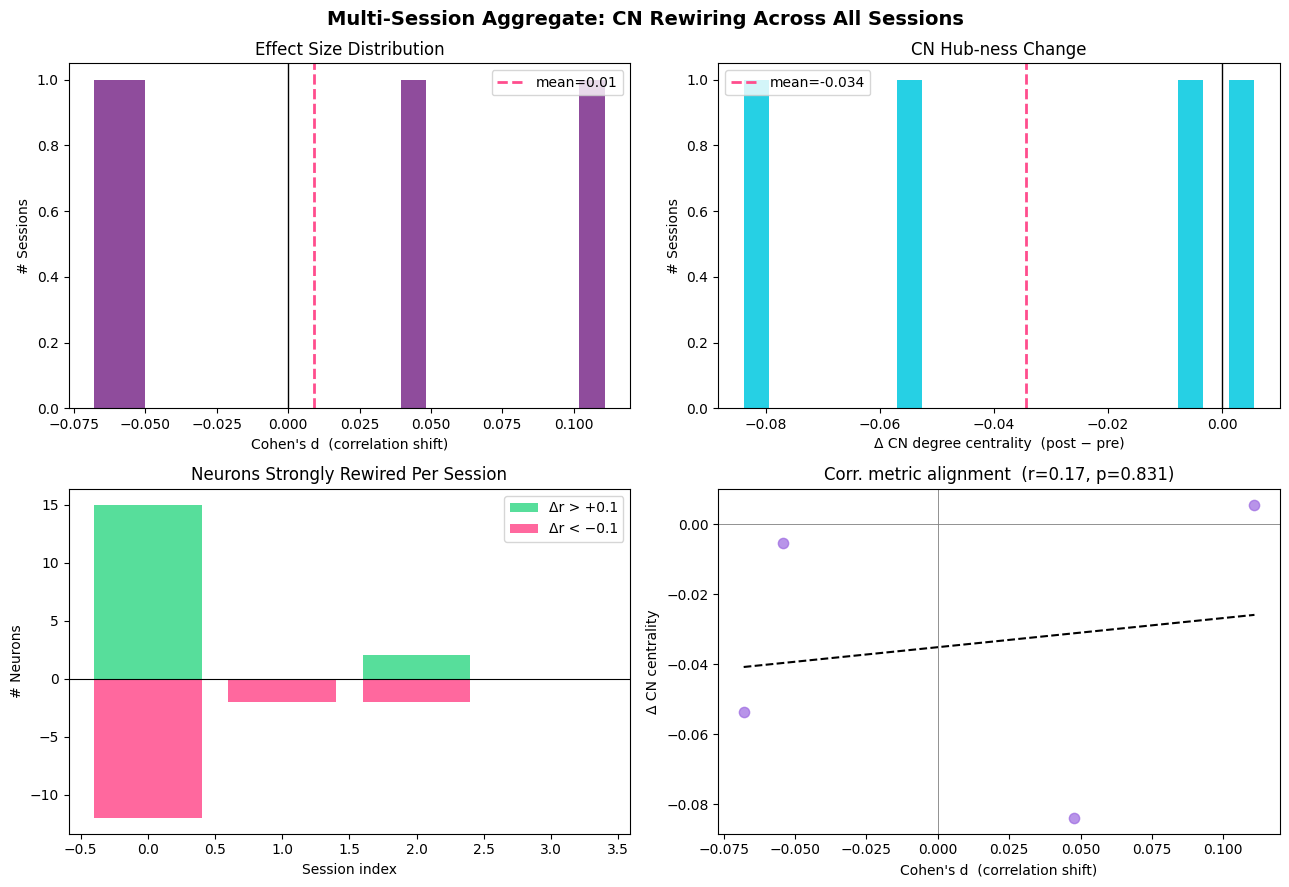


  Saved → multi_aggregate.png

  ── Step C: per-animal learning curves ──────────────────────


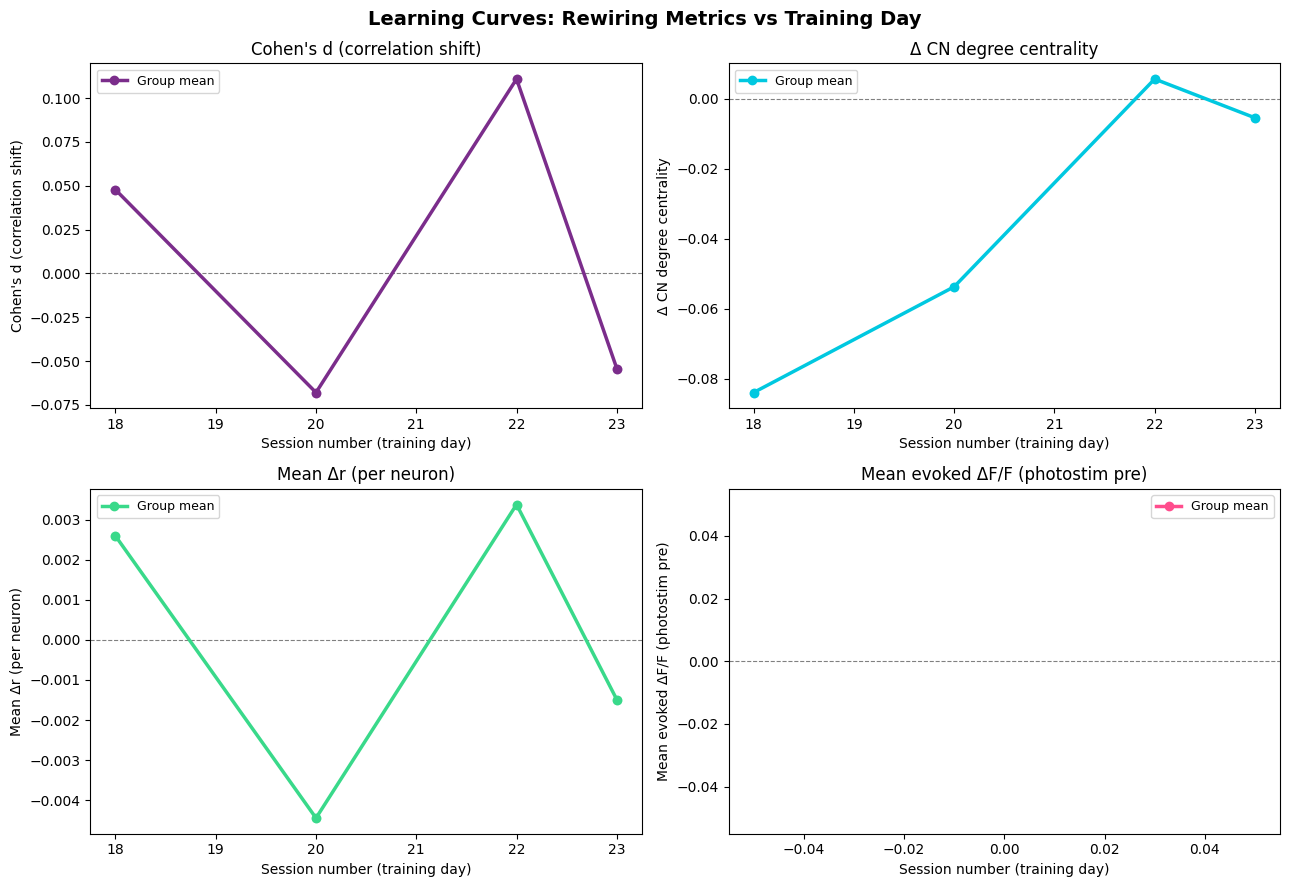

  Saved → learning_curves.png

  ── Step D: linear mixed-effects model ──────────────────────

── Mixed-effects models  (DV ~ session_number | subject_id) ────
  Mean Δr                  : insufficient data
  Cohen's d                : insufficient data
  Δ CN centrality          : insufficient data

  ── Step E: photostim connectivity timecourse ────────────────────


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.7.0 because version 2.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


ValueError: cannot convert float NaN to integer

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION  ← edit these variables, then run all cells
# ════════════════════════════════════════════════════════════════════════════


# Select a mouse 
subject_id = 754303

metadata = pd.read_csv(os.path.join('/data/', 'metadata', 'bci_metadata.csv'))

# Look at its metadata, sorted by 'session_number'
this_mouse_metadata = metadata[metadata['subject_id']==subject_id].sort_values(by='session_number')

# Select a session for this mouse 
SESSION = this_mouse_metadata.name.values[2]
print('Selected session is', SESSION)


#SESSION      = "single-plane-ophys_754303_2025-01-27_20-01-31_processed_2025-08-07_06-00-10"
DATA_ROOT    = "/data/brain-computer-interface-v2"
METADATA_CSV = "/data/metadata/bci_metadata.csv"
SAVE_DIR     = "./results"
CACHE_DIR    = "./session_cache"
RUN_MULTI    = True   # set False to run single-session only


# ════════════════════════════════════════════════════════════════════════════
# MAIN — FULL PIPELINE
# ════════════════════════════════════════════════════════════════════════════

save_dir  = Path(SAVE_DIR);  save_dir.mkdir(parents=True, exist_ok=True)
cache_dir = Path(CACHE_DIR); cache_dir.mkdir(parents=True, exist_ok=True)

# ── SINGLE-SESSION DEEP DIVE ─────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  BCI Neural Rewiring Analysis — Allen Institute Hackathon 2025")
print(f"{'='*65}")
print(f"\n[1/2]  Single-session deep dive")
print(f"  Session  : {SESSION}")
print(f"  Figures  : {save_dir}\n")

# nwbfile = load_session(SESSION, data_root=DATA_ROOT)
# data    = extract_session_data(nwbfile)
# print(f"  dff shape    : {data['cleaned_dff'].shape}")
# print(f"  CN index     : {data['cn_clean']}")
# print(f"  Frame rate   : {data['frame_rate']:.1f} Hz")
# print(f"  Epochs       : {data['epoch_table'].stimulus_name.tolist()}\n")

# aim1 = aim1_correlation_rewiring(data, session_name,        save_dir=str(save_dir))
# aim2 = aim2_photostim_validation(data, session_name, aim1,  save_dir=str(save_dir))
# aim3 = aim3_graph_theory(data, session_name, aim1,          save_dir=str(save_dir))
# bonus_spatial_gradient(data, session_name, aim1,            save_dir=str(save_dir))

# ── MULTI-SESSION ─────────────────────────────────────────────────────────────
if RUN_MULTI:
    print(f"\n[2/2]  Multi-session analysis")
    metadata = pd.read_csv(METADATA_CSV)
    print(f"  Sessions in metadata : {len(metadata)}")
    print(f"  Unique subjects      : {metadata['subject_id'].nunique()}")
    print(f"  Cache directory      : {cache_dir}\n")

    # ── Step A: run all sessions (cached) ────────────────────────────────────
    print("  ── Step A: per-session pipeline (Aims 1 + 3) ──────────────────")
    records = []
    for _, row in metadata.iterrows():

        if row["name"] in ['single-plane-ophys_740369_2025-01-09_17-18-37_processed_2025',
                           'single-plane-ophys_740369_2025-01-09_17-18-37_processed_2025-08-06_03-49-53',
                           'single-plane-ophys_740369_2025-01-13_17-31-04_processed_2025',
                           'single-plane-ophys_740369_2025-02-03_19-18-31_processed_2025',
                           'single-plane-ophys_740369_2025-02-03_19-18-31_processed_2025-08-03_23-27-56',
                           'single-plane-ophys_740369_2025-01-30_18-44-54_processed_2025',
                           'single-plane-ophys_754303_2025-01-22_18-22-38_processed_2025-08-06_18-52-36']:
            continue
        
        if '740369' in row['name']:
            continue
            
        try:
            result = run_session_cached(row["name"], DATA_ROOT, cache_dir)
        except:
            print(row["name"])
        if result is not None:
            records.append(result)

    print(f"\n  Completed: {len(records)} / {len(metadata)} sessions\n")

    if len(records) < 3:
        print("  ⚠  Fewer than 3 sessions succeeded — skipping aggregate plots.")
    else:
        df_all = multi_session_aggregate(records)
        df_all.to_csv(save_dir / "all_sessions_results.csv", index=False)
        print(f"  Saved → all_sessions_results.csv  ({len(df_all)} rows)\n")

        # ── Step B: aggregate summary plots ──────────────────────────────────
        print("  ── Step B: aggregate summary plots ────────────────────────")
        plot_aggregate(df_all, str(save_dir))

        # ── Step C: per-animal learning curves ───────────────────────────────
        print("\n  ── Step C: per-animal learning curves ──────────────────────")
        plot_learning_curves(df_all, metadata, str(save_dir))

        # ── Step D: linear mixed-effects model ───────────────────────────────
        print("\n  ── Step D: linear mixed-effects model ──────────────────────")
        mixed_effects_model(df_all, metadata, str(save_dir))

    # ── Step E: photostim connectivity timecourse (independent of Step A) ────
    print("\n  ── Step E: photostim connectivity timecourse ────────────────────")
    # photostim_connectivity_timecourse(metadata, DATA_ROOT, str(save_dir), cache_dir)

print(f"\n{'='*65}")
print(f"  Done.  All outputs in: {save_dir}")
print(f"{'='*65}\n")
